Databricks notebook source
MAGIC %md
MAGIC
MAGIC ## UMAP visualization of patients' diagnoses based on male infertility status
MAGIC
MAGIC Note: This visualizes all phenotypes not related to infertility

COMMAND ----------

In [1]:
import os
os.chdir('/Users/fengxie/Documents/Logistic_Regression_Python_Stanford/Logistic_Regression_Python_MI')
from MI_Functions import *

COMMAND ----------

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy.core.multiarray
import numpy as np
import os
import re
import scipy
from scipy import stats
from scipy.stats import mstats
from scipy.stats import mannwhitneyu
from scikit_posthocs import posthoc_dunn
import matplotlib
import re

COMMAND ----------

MAGIC %md
MAGIC ## 'Import' functions

COMMAND ----------

MAGIC %run MI_Functions.py

COMMAND ----------

In [3]:
# feature corresponds to column of interest 
feature = 'male infertility status'

COMMAND ----------

In [4]:
all_demo_df = pd.read_pickle("male_infertility_validation/tables/umap/demo_all.pkl")

COMMAND ----------

MAGIC %md
MAGIC ## Read in 'X', the 2D representations of patients' diagnoses

COMMAND ----------

In [5]:
X = pd.read_pickle("male_infertility_validation/tables/umap/mi_vas_only.pkl").sort_values(by='index').copy()

COMMAND ----------

MAGIC %md
MAGIC ## Create X_embedded (numpy array)

COMMAND ----------

In [6]:
X_embedded = make_X_embedded(X)

COMMAND ----------

In [7]:
 display(X.head(5))

,index,0,1
0,0,-0.397915,-2.422086
1,1,2.224567,-8.332384
2,2,-4.776010,-11.833568
3,3,3.084123,-10.944121
4,4,3.094965,-13.646980


COMMAND ----------

MAGIC %md
MAGIC ## Read in 'y', which preserves each patient's male infertility status (it is not preserved after performing dimensionality reduction) as well as demographic features

COMMAND ----------

In [8]:
y_all = pd.read_pickle("male_infertility_validation/tables/umap/y_all.pkl").sort_values(by='index').copy()

COMMAND ----------

MAGIC %md
MAGIC ### Convert y (which can be any feature) to series of feature of interest

COMMAND ----------

In [9]:
y = y_all[feature]

COMMAND ----------

MAGIC %md
MAGIC ## Visualize UMAP

COMMAND ----------

UMAP based on Male Infertility Status


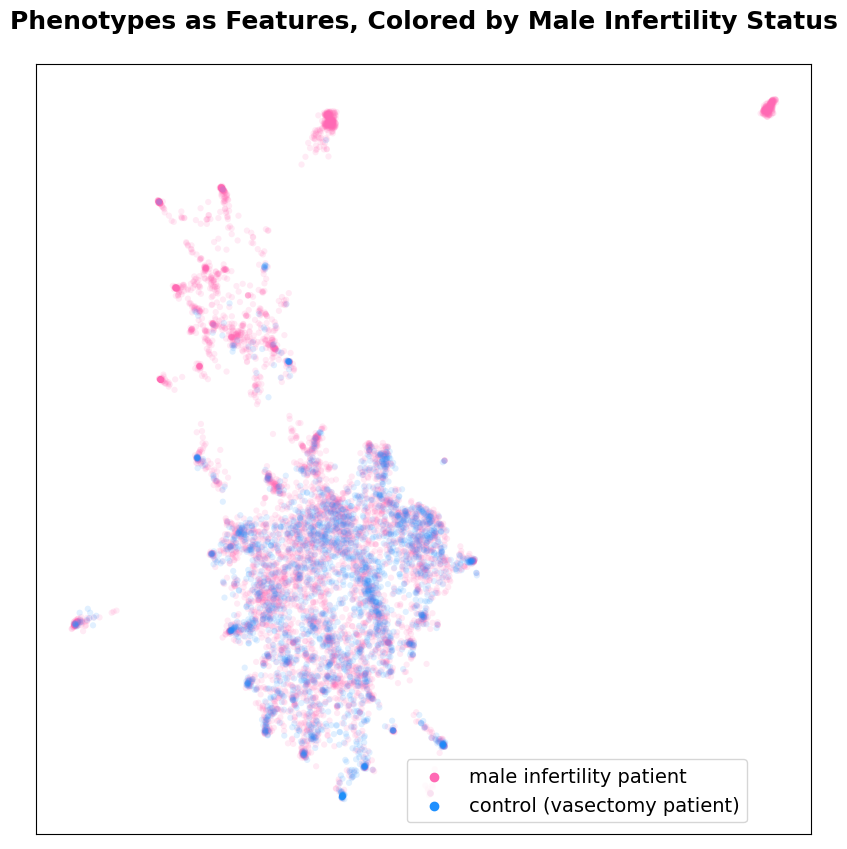

In [10]:
visualize_UMAP_data(X_embedded=X_embedded, 
                    y=y,
                    hue_order=y.unique(), 
                    feature=feature.title(),
                    bbox_to_anchor=(0.465, 0.11),
                    alpha=0.135,
                    palette=['hotpink', 'dodgerblue'],
                    figure_size=(10, 10),
                    label_axes=False,
                    save=True,
                    file_name="fx_umap_mi_all")

COMMAND ----------

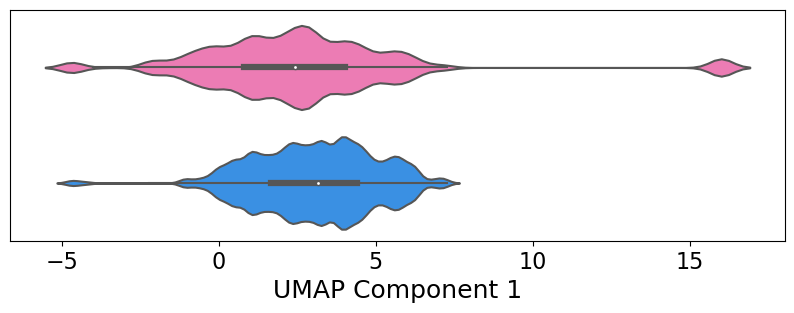

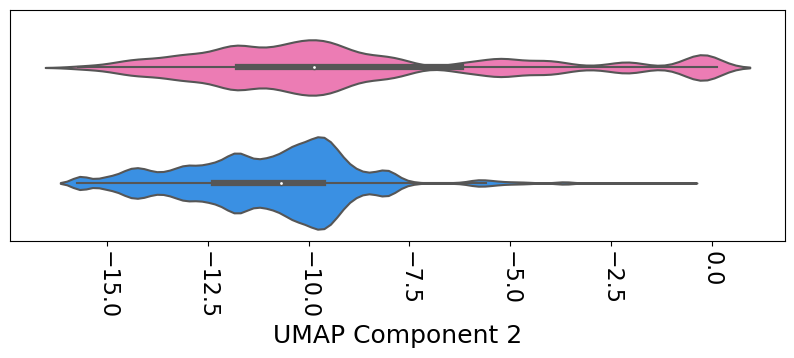

In [11]:
make_UMAP_violin_plots(X_embedded=X_embedded, 
                       y_values=y.values, 
                       palette=['hotpink', 'dodgerblue'],
                       save=True,
                       filename_UMAP_1='fx_umap_mi_all_violin1',
                       filename_UMAP_2='fx_umap_mi_all_violin2')

COMMAND ----------

MAGIC %md
MAGIC ## Statistics

COMMAND ----------

MAGIC %md
MAGIC ### Mann-Whitney U test

COMMAND ----------

In [12]:
print(color.BOLD + f"Mann-Whitney U test for logistic regression cohort:" + color.END)
cat_1 = X_embedded[y.values == y.unique()[0] ,:]
cat_2 = X_embedded[y.values == y.unique()[1] ,:]
print('Axis 1: ', mannwhitneyu(cat_1[:,0], cat_2[:,0]))
print('Axis 2: ', mannwhitneyu(cat_1[:,1], cat_2[:,1]))
print('\n')

Mann-Whitney U test for logistic regression cohort:
Axis 1:  MannwhitneyuResult(statistic=5627387.0, pvalue=8.25371823361755e-37)
Axis 2:  MannwhitneyuResult(statistic=8711591.0, pvalue=1.7953400693103142e-85)




COMMAND ----------